# Diabetes Dataset Analysis

This notebook reproduces and documents the steps from `diabetes-analysis.py`: data loading, cleaning, outlier removal, visualization, scaling, and saving artifacts.

Place `diabetes.csv` in the same folder as this notebook before running cells.

## 1) Open active notebook and set metadata

Expected environment: Python 3.8+. Required packages: pandas, numpy, matplotlib, seaborn, scikit-learn, joblib, pytest (for tests).
Kernel metadata is set in the notebook metadata.

In [1]:
# Print environment info for reproducibility
import sys, platform
print('Python executable:', sys.executable)
print('Python version:', sys.version)
print('Platform:', platform.platform())

Python executable: c:\Program Files\Python311\python.exe
Python version: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
Platform: Windows-10-10.0.26100-SP0


## 2) Import required libraries

Import standard and third-party modules and print versions.

In [2]:
# Imports and versions
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('matplotlib', matplotlib.__version__)
print('seaborn', sns.__version__)

pandas 2.3.3
numpy 2.2.5
matplotlib 3.10.1
seaborn 0.13.2


## 3) Load dataset or inputs

Load `diabetes.csv` from the notebook folder using a safe helper that works both in notebooks and scripts.

In [3]:
# Locate dataset (notebook-friendly)
nb_dir = Path('.').resolve()  # current folder where notebook is opened
csv_path = nb_dir / 'diabetes.csv'
print('Looking for dataset at:', csv_path)
if not csv_path.exists():
    raise FileNotFoundError(f'Could not find {csv_path}. Place diabetes.csv in the same folder as this notebook.')

data = pd.read_csv(csv_path)
print('Original dataset shape:', data.shape)
data.head()

Looking for dataset at: C:\Users\MSI\OneDrive\Desktop\git hub my\uom\uom\session 1\intermediate python\housing-price-pediction\uom\diabetes\diabetes.csv
Original dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4) Preprocess and validate data

Replace zeros with NaN for medically-impossible zeros and show validation checks.

In [11]:
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with NaN and show missing counts
data[cols_to_check] = data[cols_to_check].replace(0, np.nan)
print('Missing before drop:')
print(data[cols_to_check].isna().sum())

# Basic dtype and null checks
print('\nDtypes:\n', data.dtypes)
assert 'Outcome' in data.columns, 'Outcome column missing'

Missing before drop:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Dtypes:
 Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [5]:
# Drop missing and duplicates (keep a copy of original if needed)
df_clean = data.copy()
df_clean.dropna(inplace=True)
df_clean.drop_duplicates(inplace=True)
print('Cleaned dataset shape:', df_clean.shape)
df_clean.head()

Cleaned dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 5) Define core functions and classes

Implement small, testable helper functions (pure functions where possible).

In [6]:
def remove_outliers(df, column):
    """Remove univariate outliers using the IQR rule. Returns a filtered DataFrame."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Example (pure) function docstring test
import inspect
print(inspect.getsource(remove_outliers))

def remove_outliers(df, column):
    """Remove univariate outliers using the IQR rule. Returns a filtered DataFrame."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]



## 6) Add unit tests for functions

We add a tiny pytest test file under `tests/` to validate the preprocessing behavior. Running tests is optional in this notebook; instructions follow in a later section.

In [7]:
# Write a small pytest-style test file to tests/test_preprocessing.py
tests_dir = Path('tests')
tests_dir.mkdir(exist_ok=True)
test_file = tests_dir / 'test_preprocessing.py'
test_file.write_text('''import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from math import isclose

# Reuse the remove_outliers function by importing from the notebook context is not trivial,
# so we include a small local test using an inline implementation.

def remove_outliers_local(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]


def test_remove_outliers_basic():
    df = pd.DataFrame({'x': [1,2,3,4,100]})
    filtered = remove_outliers_local(df, 'x')
    assert 100 not in filtered['x'].values

''')
print('Wrote test file:', test_file)

Wrote test file: tests\test_preprocessing.py


## 7) Run tests using VS Code Test Explorer (instructions)

To run tests locally from the command line: `pytest -q --maxfail=1`. In VS Code, use the Test Explorer after installing the Python extension.

In [12]:
# 8) Execute preprocessing: remove outliers for the chosen columns
df_processed = df_clean.copy()
for col in cols_to_check:
    before = df_processed.shape[0]
    df_processed = remove_outliers(df_processed, col)
    after = df_processed.shape[0]
    print(f'Removed outliers from {col}: {before - after} rows removed')

print('\nShape after outlier removal:', df_processed.shape)

Removed outliers from Glucose: 5 rows removed
Removed outliers from BloodPressure: 45 rows removed
Removed outliers from SkinThickness: 1 rows removed
Removed outliers from Insulin: 27 rows removed
Removed outliers from BMI: 9 rows removed

Shape after outlier removal: (681, 9)


## 9) Debug failing tests and inspect output pane

If tests fail, open the `tests/test_preprocessing.py` file and use print/inspection or run `pytest -q` for a stacktrace. You can also use `pdb` to set breakpoints in code cells.

## 10) Add logging and assertions

Configure basic logging and add runtime assertions to detect inconsistent states.

In [13]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')
logger = logging.getLogger('diabetes-notebook')
logger.info('Starting preprocessing steps')

# Simple assertion example
assert not df_processed.empty, 'Processed DataFrame is empty after cleaning/outlier removal'
logger.info('Assertions passed — data not empty')

2025-10-25 14:10:24,925 INFO: Starting preprocessing steps
2025-10-25 14:10:24,926 INFO: Assertions passed — data not empty
2025-10-25 14:10:24,926 INFO: Assertions passed — data not empty


## 11) Visualize intermediate results

Include correlation heatmap, outcome distribution pie chart, and boxplots for the cleaned columns.

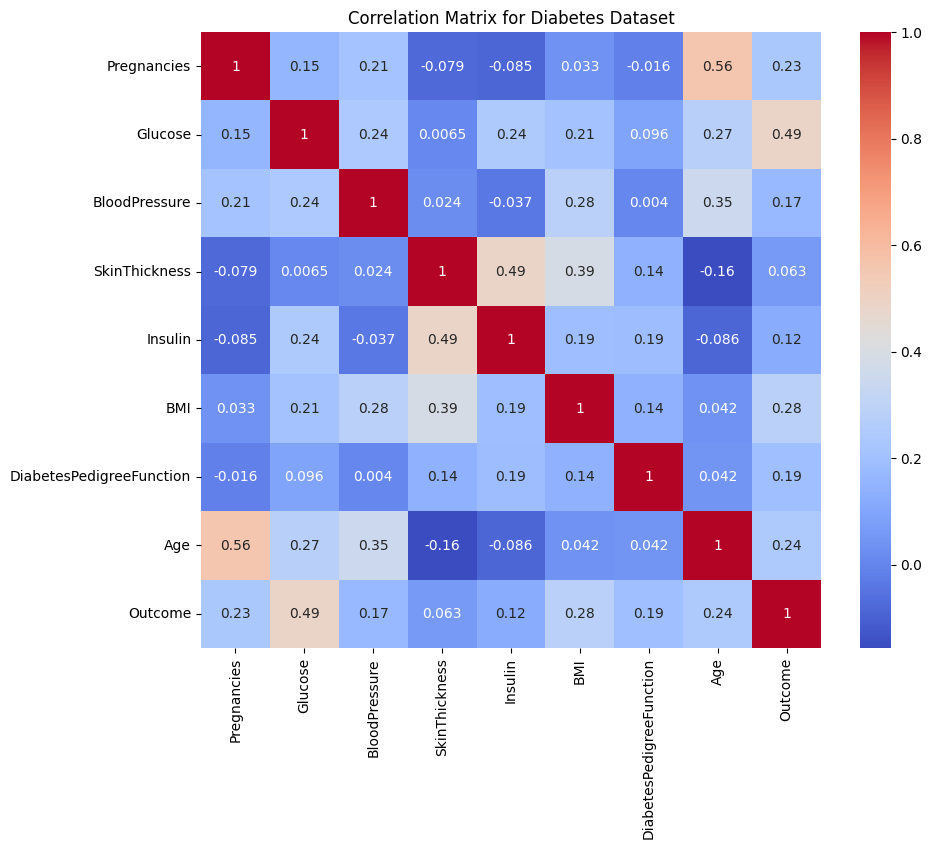

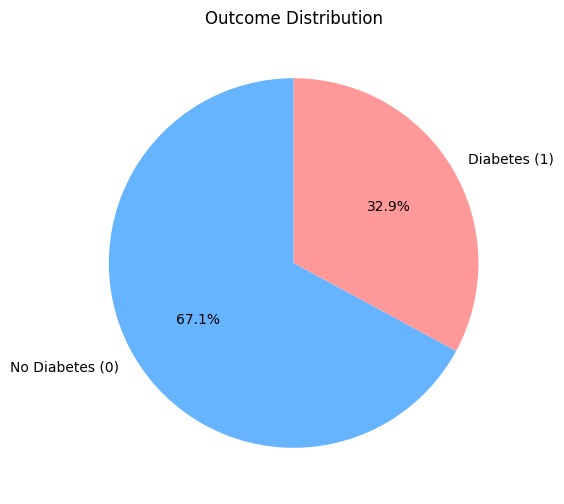

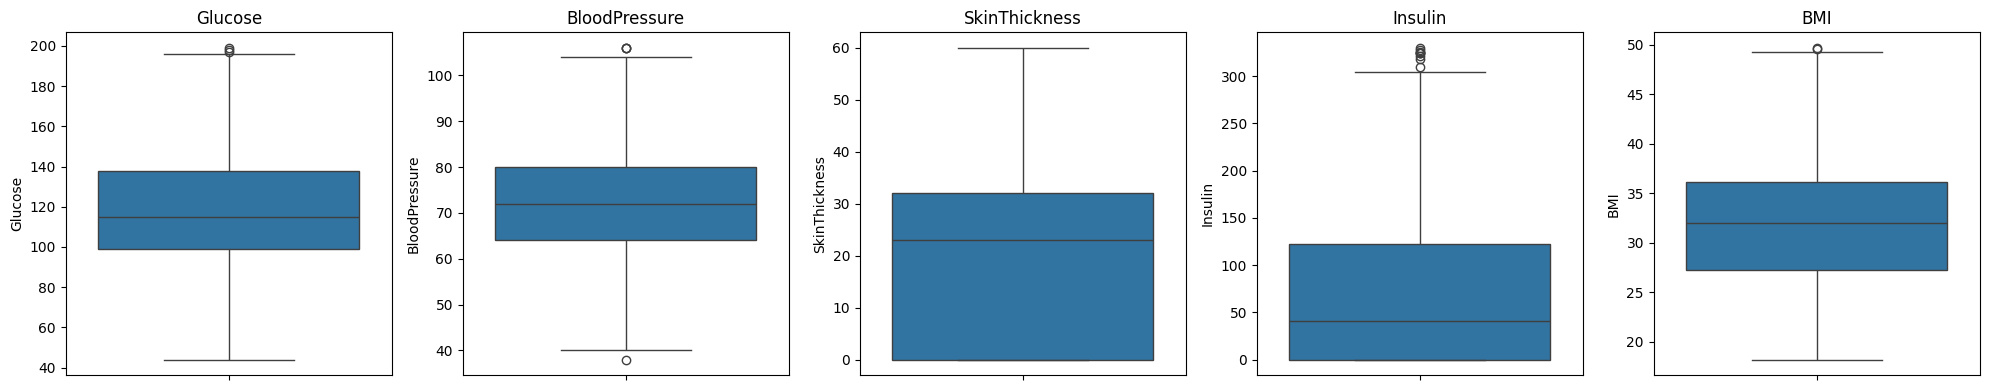

In [14]:
%matplotlib inline
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Diabetes Dataset')
plt.show()

plt.figure(figsize=(6,6))
outcome_counts = df_processed['Outcome'].value_counts()
plt.pie(outcome_counts, labels=['No Diabetes (0)', 'Diabetes (1)'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Outcome Distribution')
plt.show()

fig, axes = plt.subplots(1, len(cols_to_check), figsize=(20, 4))
for i, col in enumerate(cols_to_check):
    sns.boxplot(y=df_processed[col], ax=axes[i])
    axes[i].set_title(f"{col}")
plt.tight_layout()
plt.show()

## 12) Save artifacts and checkpoints

Serialize the scaler and processed dataset into a deterministic artifacts directory.

In [15]:
# Feature scaling and save artifacts
scaler = StandardScaler()
features = df_processed.drop('Outcome', axis=1)
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df['Outcome'] = df_processed['Outcome'].values

artifacts = nb_dir / 'artifacts'
artifacts.mkdir(exist_ok=True)
scaler_path = artifacts / 'scaler_diabetes.pkl'
joblib.dump(scaler, scaler_path)
processed_path = artifacts / 'processed_diabetes.csv'
scaled_df.to_csv(processed_path, index=False)
print('Saved scaler to:', scaler_path)
print('Saved processed CSV to:', processed_path)

Saved scaler to: C:\Users\MSI\OneDrive\Desktop\git hub my\uom\uom\session 1\intermediate python\housing-price-pediction\uom\diabetes\artifacts\scaler_diabetes.pkl
Saved processed CSV to: C:\Users\MSI\OneDrive\Desktop\git hub my\uom\uom\session 1\intermediate python\housing-price-pediction\uom\diabetes\artifacts\processed_diabetes.csv


## 13) Add CI/test runner command and final notes

To run tests locally: `pytest -q --maxfail=1`. For CI, include the same command in your pipeline.

Next steps: add train/test split, model training/evaluation, and more comprehensive tests.